In [1]:
import warnings
# Suppress all warnings
warnings.filterwarnings("ignore")

In [2]:
from dotenv import load_dotenv
load_dotenv()

True

In [3]:
from typing import Annotated, Literal, Sequence, TypedDict
from langchain_classic import hub
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import PromptTemplate
from pydantic import BaseModel, Field
from langgraph.graph.message import add_messages
from langgraph.prebuilt import tools_condition
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import Chroma
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.tools import create_retriever_tool
from langgraph.graph import END, StateGraph, START
from langgraph.prebuilt import ToolNode

USER_AGENT environment variable not set, consider setting it to identify your requests.


In [4]:
import os
os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY")
os.environ["HUGGINGFACEHUB_API_TOKEN"] = os.getenv("HUGGINGFACEHUB_API_TOKEN")
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
os.environ["LANGSMITH_API_KEY"] = os.getenv("LANGSMITH_API_KEY")
os.environ["LANGSMITH_TRACING_V2"] = "true"
os.environ["LANGSMITH_ENDPOINT"] = "https://api.smith.langchain.com"
os.environ["LANGSMITH_PROJECT_NAME"] = "Agentic RAG Project"

In [5]:
from langchain_tavily import TavilySearch



# Initialize the tool
tavily_tool = TavilySearch(
    max_results=5
)


In [6]:
from langchain_huggingface import HuggingFaceEmbeddings
embeddings=HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")

In [263]:
from langchain_groq import ChatGroq
llm=ChatGroq(model_name="llama-3.3-70b-versatile")

In [ ]:
from langchain_google_genai import ChatGoogleGenerativeAI
llm = ChatGoogleGenerativeAI(model="gemini-3.5-flash", temperature=0.3)
#gemini-3.1-flash-lite

In [187]:
urls=["https://breathedreamgo.com/india-travel-guide/"]

In [188]:
#from langchain_community.document_loaders import SeleniumURLLoader
docs=[WebBaseLoader(url).load() for url in urls]

In [192]:
docs_list=[item for sublist in docs for item in sublist]

In [194]:
text_splitter=RecursiveCharacterTextSplitter.from_tiktoken_encoder(chunk_size=100,chunk_overlap=10)
texts=text_splitter.split_documents(docs_list)

In [12]:
from langchain_classic.retrievers import EnsembleRetriever
from langchain_community.retrievers import BM25Retriever

In [197]:
vectorstore=Chroma.from_documents(
    documents=texts,
    collection_name="Indian_tourist_guide",
    embedding=embeddings)

In [200]:
# 3. Setup Lexical Keyword Retriever (BM25)
bm25_retriever = BM25Retriever.from_documents(texts)
bm25_retriever.k = 3

vector_retriever = vectorstore.as_retriever(search_kwargs={"k": 10})

# 4. Combine into an Ensemble Retriever
ensemble_retriever = EnsembleRetriever(
    retrievers=[bm25_retriever, vector_retriever],
    weights=[0.3, 0.7] # Balance between keyword and vector results
)

In [ ]:
#ensemble_retriever.invoke("Best places to visit inIndia?")

[Document(metadata={'source': 'https://breathedreamgo.com/india-travel-guide/', 'title': 'India Travel Guide - Breathedreamgo', 'description': 'The ultimate India Travel Guide. Everything you need know to visit India including top destinations, safety tips, budget advice, best tours, and more.', 'language': 'en-US'}, page_content='The best places to visit in Goa\n\nWhere should I go in Rajasthan?\n\nGuide to Rajasthan\nThe sacred and the profane at the Pushkar Camel Fair\n\nWhere should I go in Kerala?\n\nIdeal 2-week Kerala itinerary\xa0\nTravel Tips for Kerala\nBest places to visit in Kerala'),
 Document(metadata={'description': 'The ultimate India Travel Guide. Everything you need know to visit India including top destinations, safety tips, budget advice, best tours, and more.', 'source': 'https://breathedreamgo.com/india-travel-guide/', 'title': 'India Travel Guide - Breathedreamgo', 'language': 'en-US'}, page_content='What are the best destinations and tourist attractions in India

In [15]:
from flashrank import Ranker
from langchain_community.document_compressors import FlashrankRerank
from langchain_classic.retrievers import ContextualCompressionRetriever

In [202]:

# Initialize the Ranker client first
flashrank_client = Ranker(model_name="ms-marco-MiniLM-L-12-v2")

# Pass the client explicitly to bypass the validation bug
compressor = FlashrankRerank(client=flashrank_client, top_n=3)
# 2. Initialize the FlashRank compressor
#compressor = FlashrankRerank(top_n=3)

# 3. Create the Compression Retriever
compression_retriever = ContextualCompressionRetriever(
    base_compressor=compressor, 
    base_retriever=ensemble_retriever
)

In [203]:
retriever_tool = create_retriever_tool(
    name="Indian_tourist_Retriever",
    retriever=compression_retriever,
    description="A guide for Indian tourist information."
)

In [204]:
compression_retriever.invoke("Best places to visit in India?")

[Document(metadata={'id': 3, 'relevance_score': 0.9999558, 'source': 'https://breathedreamgo.com/india-travel-guide/', 'language': 'en-US', 'title': 'India Travel Guide - Breathedreamgo', 'description': 'The ultimate India Travel Guide. Everything you need know to visit India including top destinations, safety tips, budget advice, best tours, and more.'}, page_content='Where are the best places to visit in India?\nThe best places to visit in India are the ones that call you. They may or may not be the most well-known. Many people feel they have to visit the Golden Triangle – Delhi, Agra for the Taj Mahal, and Jaipur – on their first trip to India. But you don’t. India has amazing places all over the country, some of which are not well publicized.'),
 Document(metadata={'id': 4, 'relevance_score': 0.9995517, 'language': 'en-US', 'description': 'The ultimate India Travel Guide. Everything you need know to visit India including top destinations, safety tips, budget advice, best tours, and

In [264]:
tools = [retriever_tool,tavily_tool]
tool_node=ToolNode(tools)
llm_with_tools=llm.bind_tools(tools)

In [19]:
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]

In [265]:
from langchain_core.messages import  SystemMessage,HumanMessage
def ai_assistant(state:AgentState):
    print("---CALL AGENT---")
    messages = state['messages']
    print(f"this is my message: {messages}")
    
    if len(messages)>1:
        print("---CALLING LLM---")
        response=llm.invoke(messages[-1].content)
        return {"messages": [response]}
    else:
        print("---CALLING LLM WITH TOOLS---")
        messages=[SystemMessage(content="""You are a helpful AI travel guide whose goal is to answer the user's question based on the following conditions:
        1. If the user's question is about travel in India or Indian tourism, use the retriever tool to get relevant context to answer the question.
        2. If the user's question is about current information or data, use the Tavily Search tool to get the latest information.
        3. If the user's question is about something else, use your general knowledge to answer.
        Provide a summarized output not more than 100 words.State your inability to answer if the question is not clear or if you don't have enough information. Do not provide inaccurate answers."""),
        HumanMessage(content=messages[0].content)]
        response = llm_with_tools.invoke(messages)
        return {"messages": [response]}

In [266]:
class grade(BaseModel):
    binary_score:str=Field(description="Relevance score 'yes' or 'no'")

In [267]:
def grade_documents(state:AgentState)->Literal["Output_Generator", "Query_Rewriter"]:
    llm_with_structure_op=llm.with_structured_output(grade)
    
    prompt=PromptTemplate(
        template="""You are a grader deciding if the data or context is relevant to a user’s question.
                    Here is the data or context: {context}
                    Here is the user’s question: {question}
                    If the data or context talks about or contains information related to the user’s question, mark it as relevant. 
                    Give a 'yes' or 'no' answer to show if the information is relevant to the question.""",
                    input_variables=["context", "question"]
                    )
    chain = prompt | llm_with_structure_op
    
    messages = state["messages"]
    print(f"message for the grader: {messages}")
    last_message = messages[-1]
    question = messages[0].content
    docs = last_message.content
    scored_result = chain.invoke({"question": question, "context": docs})
    score = scored_result.binary_score

    if score == "yes":
        print("---DECISION: CONTEXT RELEVANT---")
        return "generator" #this should be a node name
    else:
        print("---DECISION: CONTEXT NOT RELEVANT---")
        return "rewriter" #this should be a node name

In [268]:
def generate(state:AgentState):
    print("---GENERATE---")
    messages = state["messages"]
    
    print(f"here is message from generate: {messages}")
    
    question = messages[0].content
    last_message = messages[-1]
    docs = last_message.content
    print(f"---CONTEXT---: {docs}")
    
    prompt=PromptTemplate(
        template="""You are an assistant for question-answering tasks. Use the following pieces of context or information to answer the question. If you don't know the answer, just say that you don't know. Use three sentences maximum and keep the answer concise.
    Question: {question} 
    Context or Information: {context} 
    Answer:""",
    input_variables=["context", "question"]
                    )
    
    final_chain = prompt | llm

    response = final_chain.invoke({"context": docs, "question": question})
    print(f"this is my response:{response}")
    
    return {"messages": [response]}

In [269]:

def rewrite(state:AgentState):
    print("---TRANSFORM QUERY---")
    messages = state["messages"]
    question = messages[0].content
    
    print(f"here is message from rewrite: {messages}")
    
    message = [HumanMessage(content=f"""Look at the input and try to reason about the underlying semantic intent or meaning. 
                    Here is the initial question: {question} 
                    Formulate an improved question: """)
       ]
    response = llm.invoke(message)
    print(f"this is my rewritten query: {response}")
    return {"messages": [response]}

In [270]:
workflow=StateGraph(AgentState)
workflow.add_node("My_AI_Assistant",ai_assistant)
workflow.add_node("tools", tool_node) 
workflow.add_node("Query_Rewriter", rewrite) 
workflow.add_node("Output_Generator", generate)

In [271]:
workflow.add_edge(START,"My_AI_Assistant")
workflow.add_conditional_edges("My_AI_Assistant",
                               tools_condition,
                               {"tools": "tools",
                                END: END,})

In [272]:
workflow.add_conditional_edges("tools",
                            grade_documents,
                            {"generator": "Output_Generator",
                            "rewriter": "Query_Rewriter"
                            }
                            )

In [273]:
workflow.add_edge("Output_Generator", END)

In [274]:
workflow.add_edge("Query_Rewriter", "My_AI_Assistant")

In [275]:
app=workflow.compile()

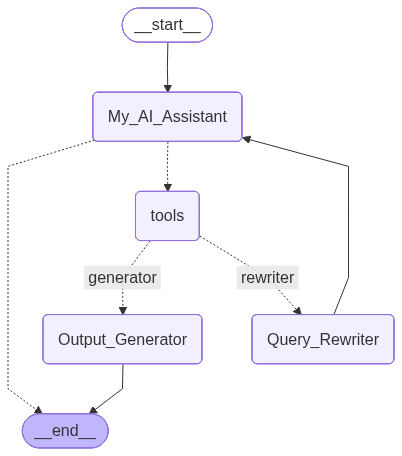

In [276]:
from IPython.display import Image, display

try:
    display(Image(app.get_graph(xray=True).draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [277]:
response_1=app.invoke({"messages":["What are the best places to visit in India?"]})

---CALL AGENT---
this is my message: [HumanMessage(content='What are the best places to visit in India?', additional_kwargs={}, response_metadata={}, id='1e03e948-42a7-4815-b62f-5435eaa83a3d')]
---CALLING LLM WITH TOOLS---


INFO:httpx:HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


message for the grader: [HumanMessage(content='What are the best places to visit in India?', additional_kwargs={}, response_metadata={}, id='1e03e948-42a7-4815-b62f-5435eaa83a3d'), AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'cbg8xsmag', 'function': {'arguments': '{"query":"best places to visit in India"}', 'name': 'Indian_tourist_Retriever'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 25, 'prompt_tokens': 1904, 'total_tokens': 1929, 'completion_time': 0.045182369, 'completion_tokens_details': None, 'prompt_time': 0.094262043, 'prompt_tokens_details': None, 'queue_time': 0.159418906, 'total_time': 0.139444412}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_45180df409', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e5b65-88ef-7132-9674-ccfc200da383-0', tool_calls=[{'name': 'Indian_tourist_Retriever', 'args': {'query': 'best places to visit

INFO:httpx:HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


this is my response:content='The best places to visit in India include the Golden Triangle (Delhi, Agra, and Jaipur), as well as other popular destinations like Rajasthan, Goa, and Kerala. Other notable places to visit are Mumbai, Rishikesh, Dharamsala, and Pondicherry, which attract a significant number of foreign tourists. Additionally, there are many offbeat locations, such as Chhattisgarh, Bundi, and Orchha, that offer unique experiences.' additional_kwargs={} response_metadata={'token_usage': {'completion_tokens': 98, 'prompt_tokens': 372, 'total_tokens': 470, 'completion_time': 0.25956882, 'completion_tokens_details': None, 'prompt_time': 0.021214255, 'prompt_tokens_details': None, 'queue_time': 0.055686615, 'total_time': 0.280783075}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'} id='lc_run--019e5b65-8fe5-7561-bf8a-319a60318bfc-0' tool_calls=[] inva

In [282]:
response_1["messages"][-1].content

'The best places to visit in India include the Golden Triangle (Delhi, Agra, and Jaipur), as well as other popular destinations like Rajasthan, Goa, and Kerala. Other notable places to visit are Mumbai, Rishikesh, Dharamsala, and Pondicherry, which attract a significant number of foreign tourists. Additionally, there are many offbeat locations, such as Chhattisgarh, Bundi, and Orchha, that offer unique experiences.'

In [278]:
response_2=app.invoke({"messages":["What are the current prime minister of India?"]})

---CALL AGENT---
this is my message: [HumanMessage(content='What are the current prime minister of India?', additional_kwargs={}, response_metadata={}, id='e6ba7809-4ef8-4919-b0dd-16126b63e8bb')]
---CALLING LLM WITH TOOLS---


INFO:httpx:HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


message for the grader: [HumanMessage(content='What are the current prime minister of India?', additional_kwargs={}, response_metadata={}, id='e6ba7809-4ef8-4919-b0dd-16126b63e8bb'), AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'wefxb9q5k', 'function': {'arguments': '{"query":"current prime minister of India","topic":"news"}', 'name': 'tavily_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 26, 'prompt_tokens': 1903, 'total_tokens': 1929, 'completion_time': 0.074159562, 'completion_tokens_details': None, 'prompt_time': 0.098262809, 'prompt_tokens_details': None, 'queue_time': 0.16171959, 'total_time': 0.172422371}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_3272ea2d91', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e5b67-5da2-7742-a4ff-f9de77858b8d-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'current prime minister o

INFO:httpx:HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


---DECISION: CONTEXT RELEVANT---
---GENERATE---
here is message from generate: [HumanMessage(content='What are the current prime minister of India?', additional_kwargs={}, response_metadata={}, id='e6ba7809-4ef8-4919-b0dd-16126b63e8bb'), AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'wefxb9q5k', 'function': {'arguments': '{"query":"current prime minister of India","topic":"news"}', 'name': 'tavily_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 26, 'prompt_tokens': 1903, 'total_tokens': 1929, 'completion_time': 0.074159562, 'completion_tokens_details': None, 'prompt_time': 0.098262809, 'prompt_tokens_details': None, 'queue_time': 0.16171959, 'total_time': 0.172422371}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_3272ea2d91', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e5b67-5da2-7742-a4ff-f9de77858b8d-0', tool_calls=[{'name': 'tavi

INFO:httpx:HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


this is my response:content='The current Prime Minister of India is Narendra Modi. He has been mentioned in multiple news articles as the Prime Minister, with the most recent articles dated May 2026. Narendra Modi has been serving as the Prime Minister for over 12 years, as stated in one of the articles.' additional_kwargs={} response_metadata={'token_usage': {'completion_tokens': 58, 'prompt_tokens': 1714, 'total_tokens': 1772, 'completion_time': 0.186569879, 'completion_tokens_details': None, 'prompt_time': 0.092752798, 'prompt_tokens_details': None, 'queue_time': 0.054880152, 'total_time': 0.279322677}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'} id='lc_run--019e5b67-64d3-7ab1-bc87-49fb09522560-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 1714, 'output_tokens': 58, 'total_tokens': 1772}


In [281]:
response_2["messages"][-1].content

'The current Prime Minister of India is Narendra Modi. He has been mentioned in multiple news articles as the Prime Minister, with the most recent articles dated May 2026. Narendra Modi has been serving as the Prime Minister for over 12 years, as stated in one of the articles.'